In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/heart_attack_prediction_dataset.csv')
df.head()

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


In [ ]:
df.describe()

,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,53.707977,259.877211,75.021682,0.652288,0.492982,0.896839,0.501426,0.598083,10.014284,0.495835,0.498345,5.469702,5.993690,158263.181901,28.891446,417.677051,3.489672,7.023508,0.358211
std,21.249509,80.863276,20.550948,0.476271,0.499979,0.304186,0.500026,0.490313,5.783745,0.500011,0.500026,2.859622,3.466359,80575.190806,6.319181,223.748137,2.282687,1.988473,0.479502
min,18.000000,120.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002442,0.000000,0.000000,1.000000,0.001263,20062.000000,18.002337,30.000000,0.000000,4.000000,0.000000
25%,35.000000,192.000000,57.000000,0.000000,0.000000,1.000000,0.000000,0.000000,4.981579,0.000000,0.000000,3.000000,2.998794,88310.000000,23.422985,225.500000,2.000000,5.000000,0.000000
50%,54.000000,259.000000,75.000000,1.000000,0.000000,1.000000,1.000000,1.000000,10.069559,0.000000,0.000000,5.000000,5.933622,157866.000000,28.768999,417.000000,3.000000,7.000000,0.000000
75%,72.000000,330.000000,93.000000,1.000000,1.000000,1.000000,1.000000,1.000000,15.050018,1.000000,1.000000,8.000000,9.019124,227749.000000,34.324594,612.000000,5.000000,9.000000,1.000000
max,90.000000,400.000000,110.000000,1.000000,1.000000,1.000000,1.000000,1.000000,19.998709,1.000000,1.000000,10.000000,11.999313,299954.000000,39.997211,800.000000,7.000000,10.000000,1.000000


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   object 
 3   Cholesterol                      8763 non-null   int64  
 4   Blood Pressure                   8763 non-null   object 
 5   Heart Rate                       8763 non-null   int64  
 6   Diabetes                         8763 non-null   int64  
 7   Family History                   8763 non-null   int64  
 8   Smoking                          8763 non-null   int64  
 9   Obesity                          8763 non-null   int64  
 10  Alcohol Consumption              8763 non-null   int64  
 11  Exercise Hours Per Week          8763 non-null   float64
 12  Diet                

In [ ]:
df['Heart Attack Risk'].value_counts()

,count
Heart Attack Risk,
0,5624
1,3139


In [ ]:
df = df.drop(columns=['Patient ID', 'Country', 'Hemisphere'],  errors='ignore')

In [ ]:
if 'Blood Pressure' in df.columns:
    df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True).astype(float)
    df = df.drop(columns=['Blood Pressure'])

In [ ]:
df.columns

Index(['Age', 'Sex', 'Cholesterol', 'Heart Rate', 'Diabetes', 'Family History',
       'Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week',
       'Diet', 'Previous Heart Problems', 'Medication Use', 'Stress Level',
       'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides',
       'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Continent',
       'Heart Attack Risk', 'Systolic_BP', 'Diastolic_BP'],
      dtype='object')

In [ ]:
df['Systolic_BP'].min()

90.0

In [ ]:
df['Diastolic_BP'].max()

110.0

In [ ]:
df.max()

,0
Age,90
Sex,Male
Cholesterol,400
Heart Rate,110
Diabetes,1
Family History,1
Smoking,1
Obesity,1
Alcohol Consumption,1
Exercise Hours Per Week,19.998709


In [ ]:
df

,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Continent,Heart Attack Risk,Systolic_BP,Diastolic_BP
0,67,Male,208,72,0,0,1,0,0,4.168189,...,6.615001,261404,31.251233,286,0,6,South America,0,158.0,88.0
1,21,Male,389,98,1,1,1,1,1,1.813242,...,4.963459,285768,27.194973,235,1,7,North America,0,165.0,93.0
2,21,Female,324,72,1,0,0,0,0,2.078353,...,9.463426,235282,28.176571,587,4,4,Europe,0,174.0,99.0
3,84,Male,383,73,1,1,1,0,1,9.828130,...,7.648981,125640,36.464704,378,3,4,North America,0,163.0,100.0
4,66,Male,318,93,1,1,1,1,0,5.804299,...,1.514821,160555,21.809144,231,1,5,Asia,0,91.0,88.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,60,Male,121,61,1,1,1,0,1,7.917342,...,10.806373,235420,19.655895,67,7,7,Asia,0,94.0,76.0
8759,28,Female,120,73,1,0,0,1,0,16.558426,...,3.833038,217881,23.993866,617,4,9,North America,0,157.0,102.0
8760,47,Male,250,105,0,1,1,1,1,3.148438,...,2.375214,36998,35.406146,527,4,4,South America,1,161.0,75.0
8761,36,Male,178,60,1,0,1,0,0,3.789950,...,0.029104,209943,27.294020,114,2,8,South America,0,119.0,67.0


In [ ]:
df_corr = df.copy()

In [ ]:
df_corr  = pd.get_dummies(df_corr, dtype=int)

In [ ]:
df_corr

,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,...,Sex_Male,Diet_Average,Diet_Healthy,Diet_Unhealthy,Continent_Africa,Continent_Asia,Continent_Australia,Continent_Europe,Continent_North America,Continent_South America
0,67,208,72,0,0,1,0,0,4.168189,0,...,1,1,0,0,0,0,0,0,0,1
1,21,389,98,1,1,1,1,1,1.813242,1,...,1,0,0,1,0,0,0,0,1,0
2,21,324,72,1,0,0,0,0,2.078353,1,...,0,0,1,0,0,0,0,1,0,0
3,84,383,73,1,1,1,0,1,9.828130,1,...,1,1,0,0,0,0,0,0,1,0
4,66,318,93,1,1,1,1,0,5.804299,1,...,1,0,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,60,121,61,1,1,1,0,1,7.917342,1,...,1,0,1,0,0,1,0,0,0,0
8759,28,120,73,1,0,0,1,0,16.558426,0,...,0,0,1,0,0,0,0,0,1,0
8760,47,250,105,0,1,1,1,1,3.148438,1,...,1,1,0,0,0,0,0,0,0,1
8761,36,178,60,1,0,1,0,0,3.789950,1,...,1,0,0,1,0,0,0,0,0,1


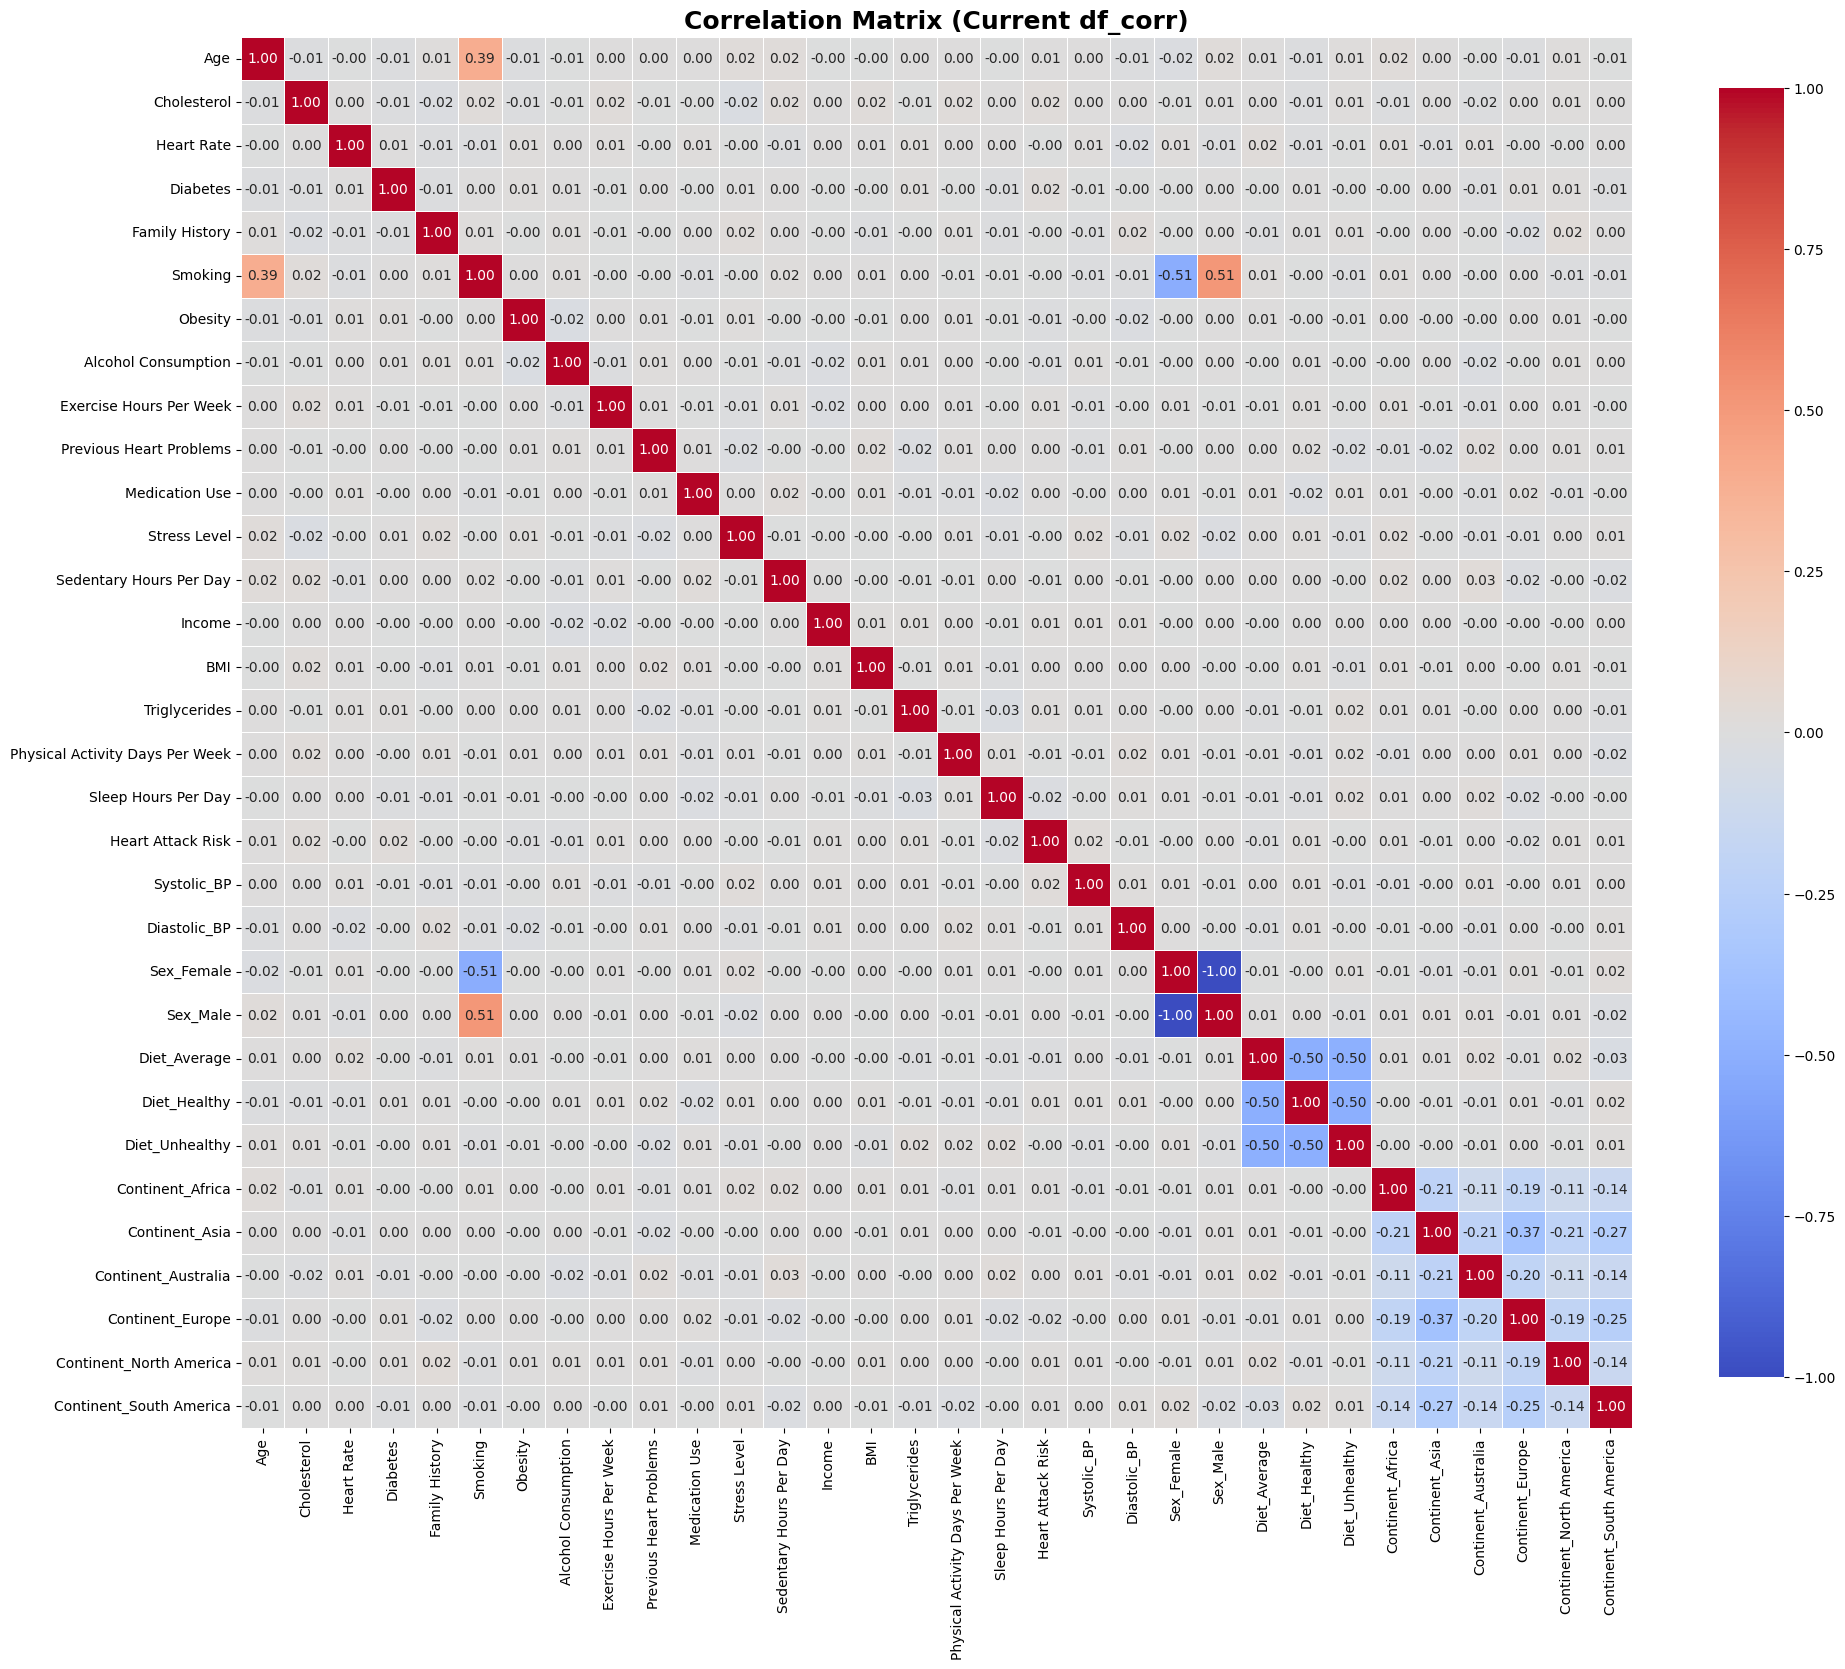

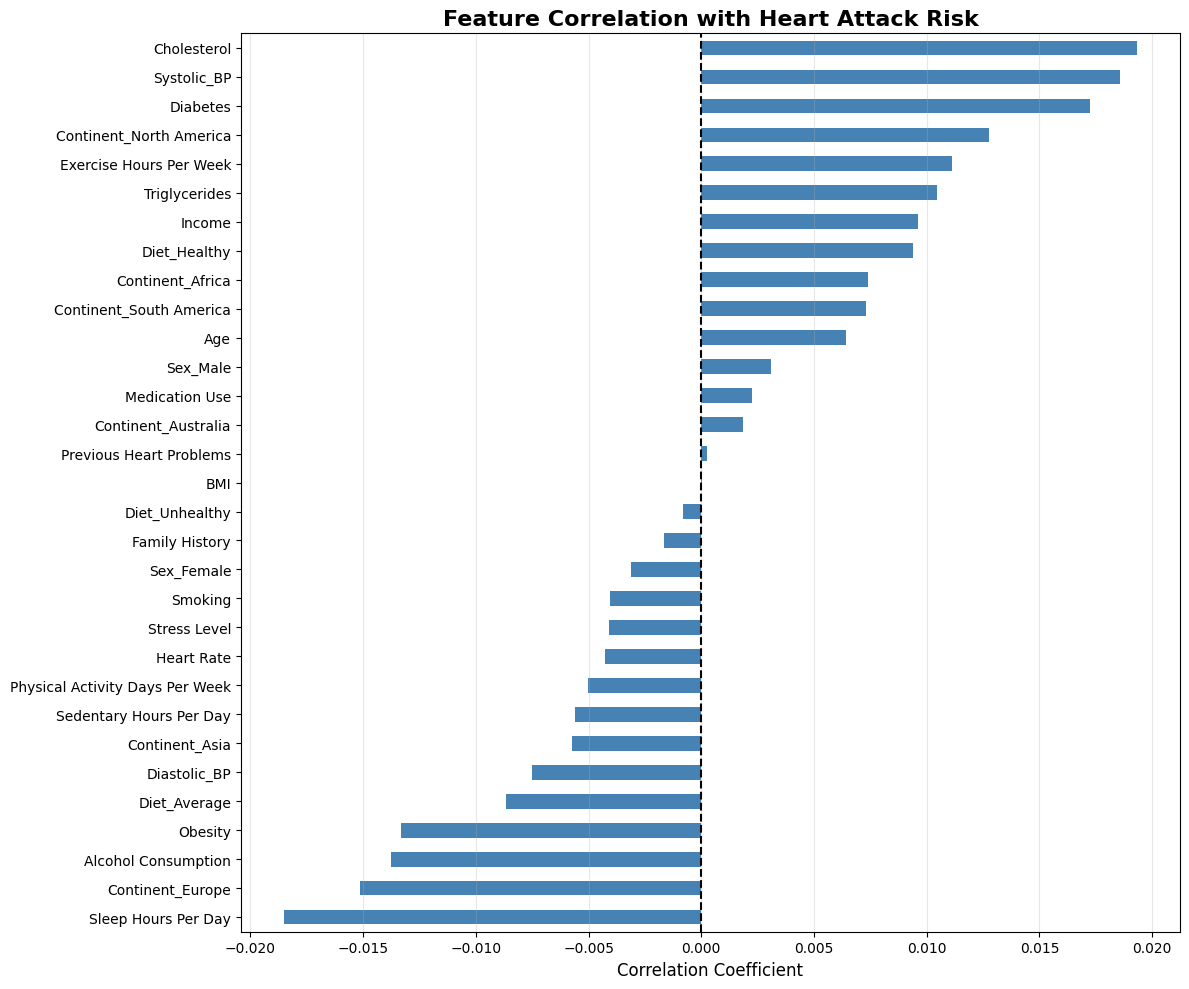

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 18))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', center=0, fmt= '.2f',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix (Current df_corr)', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

target = 'Heart Attack Risk'
correlations = df_corr.corr()[target].sort_values(ascending=False)
correlations

plt.figure(figsize=(12, 10))
correlations.drop(target).sort_values().plot(kind='barh', color='steelblue')
plt.title('Feature Correlation with Heart Attack Risk', fontsize=16, fontweight='bold')
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('correlation_with_target.png', dpi=200)
plt.show()

In [ ]:
df_clean = df.copy()

In [ ]:
y = df_clean['Heart Attack Risk']
X = df_clean.drop(columns=['Heart Attack Risk'])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight for XGBoost: {scale_pos_weight:.2f}")

scale_pos_weight for XGBoost: 1.79


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, classification_report, balanced_accuracy_score, f1_score

In [ ]:

#logreg
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer_logreg = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

preprocessor_logreg = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer_logreg, categorical_features)
    ])

pipeline_logreg = Pipeline(steps=[
    ('preprocessor', preprocessor_logreg),
    ('classifier', LogisticRegression( class_weight='balanced', penalty='l2', C=1.0, max_iter=1000, random_state=42))
])



In [ ]:
# tree-based models
categorical_transformer_tree = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop=None, handle_unknown='ignore', sparse_output=False))
])

preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', categorical_transformer_tree, categorical_features)
    ])

pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('classifier', RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42))
])

pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('classifier', XGBClassifier(scale_pos_weight=scale_pos_weight, n_estimators=100, max_depth=5, random_state=42, eval_metric='logloss'))
])

pipeline_gb = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=42))
])

In [ ]:

pipelines = {
    'Logistic Regression': pipeline_logreg,
    'Random Forest': pipeline_rf,
    'XGBoost': pipeline_xgb,
    'Gradient Boosting': pipeline_gb
}


results_baseline = {}

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    y_pred = pipeline.predict(X_test)

    roc_auc = roc_auc_score(y_test, y_proba)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results_baseline[name] = {
        'ROC-AUC': roc_auc,
        'Balanced Accuracy': balanced_acc,
        'F1-Score': f1
    }

    print(f"\n{name}:")
    print(f"  ROC-AUC: {roc_auc:.4f}")
    print(f"  Balanced Accuracy: {balanced_acc:.4f}")
    print(f"  F1-Score: {f1:.4f}")


Logistic Regression:
  ROC-AUC: 0.4945
  Balanced Accuracy: 0.4953
  F1-Score: 0.4097

Random Forest:
  ROC-AUC: 0.5106
  Balanced Accuracy: 0.5004
  F1-Score: 0.0246

XGBoost:
  ROC-AUC: 0.5147
  Balanced Accuracy: 0.5113
  F1-Score: 0.3717

Gradient Boosting:
  ROC-AUC: 0.5072
  Balanced Accuracy: 0.5017
  F1-Score: 0.0497



Logistic Regression:
------------------------------------------------------------
Confusion Matrix:
[[851 836]
 [484 458]]

True Negatives (correct 0):  851
False Positives (wrong 1):   836
False Negatives (wrong 0):   484
True Positives (correct 1):  458

Class 0 (No Risk) Recall: 0.5044 (50.4%)
Class 1 (Risk) Recall: 0.4862 (48.6%)
Class 1 (Risk) Precision: 0.3539 (35.4%)


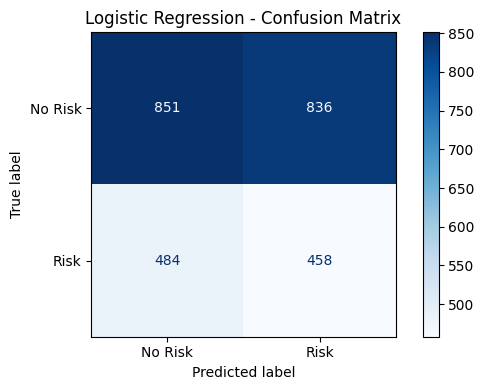


Random Forest:
------------------------------------------------------------
Confusion Matrix:
[[1667   20]
 [ 930   12]]

True Negatives (correct 0):  1667
False Positives (wrong 1):   20
False Negatives (wrong 0):   930
True Positives (correct 1):  12

Class 0 (No Risk) Recall: 0.9881 (98.8%)
Class 1 (Risk) Recall: 0.0127 (1.3%)
Class 1 (Risk) Precision: 0.3750 (37.5%)


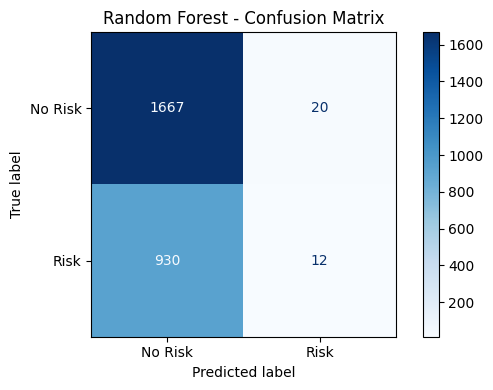


XGBoost:
------------------------------------------------------------
Confusion Matrix:
[[1100  587]
 [ 593  349]]

True Negatives (correct 0):  1100
False Positives (wrong 1):   587
False Negatives (wrong 0):   593
True Positives (correct 1):  349

Class 0 (No Risk) Recall: 0.6520 (65.2%)
Class 1 (Risk) Recall: 0.3705 (37.0%)
Class 1 (Risk) Precision: 0.3729 (37.3%)


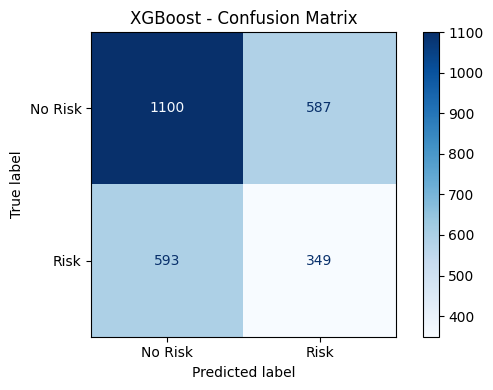


Gradient Boosting:
------------------------------------------------------------
Confusion Matrix:
[[1648   39]
 [ 917   25]]

True Negatives (correct 0):  1648
False Positives (wrong 1):   39
False Negatives (wrong 0):   917
True Positives (correct 1):  25

Class 0 (No Risk) Recall: 0.9769 (97.7%)
Class 1 (Risk) Recall: 0.0265 (2.7%)
Class 1 (Risk) Precision: 0.3906 (39.1%)


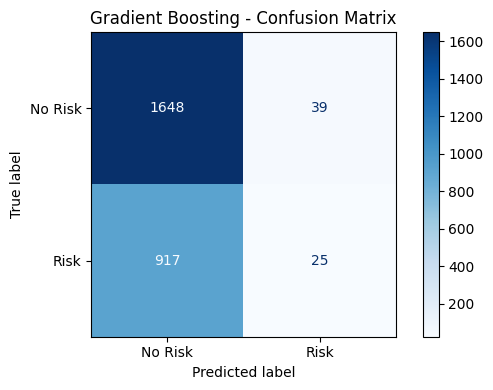

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, pipeline in pipelines.items():
    print(f"\n{name}:")
    print("-"*60)

    y_pred = pipeline.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    print("Confusion Matrix:")
    print(cm)
    print(f"\nTrue Negatives (correct 0):  {cm[0,0]}")
    print(f"False Positives (wrong 1):   {cm[0,1]}")
    print(f"False Negatives (wrong 0):   {cm[1,0]}")
    print(f"True Positives (correct 1):  {cm[1,1]}")


    tn, fp, fn, tp = cm.ravel()
    recall_0 = tn / (tn + fp) if (tn + fp) > 0 else 0
    recall_1 = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_1 = tp / (tp + fp) if (tp + fp) > 0 else 0

    print(f"\nClass 0 (No Risk) Recall: {recall_0:.4f} ({recall_0*100:.1f}%)")
    print(f"Class 1 (Risk) Recall: {recall_1:.4f} ({recall_1*100:.1f}%)")
    print(f"Class 1 (Risk) Precision: {precision_1:.4f} ({precision_1*100:.1f}%)")

    # График
    fig, ax = plt.subplots(figsize=(6, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Risk', 'Risk'])
    disp.plot(ax=ax, cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.tight_layout()
    plt.show()

In [ ]:
#Посмотрим на метрики моделей
summary = []

for name, pipeline in pipelines.items():
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    y_train_proba = pipeline.predict_proba(X_train)[:, 1]

    # ROC-AUC
    train_roc = roc_auc_score(y_train, y_train_proba)
    test_roc = roc_auc_score(y_test, y_proba)


    mean_proba = y_proba.mean()
    max_proba = y_proba.max()


    pred_at_03 = (y_proba >= 0.3).sum()
    pred_at_05 = (y_proba >= 0.5).sum()

    summary.append({
        'Model': name,
        'Train ROC-AUC': train_roc,
        'Test ROC-AUC': test_roc,
        'Overfitting': train_roc - test_roc,
        'Mean Proba': mean_proba,
        'Max Proba': max_proba,
        'Pred@0.3': pred_at_03,
        'Pred@0.5': pred_at_05
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

              Model  Train ROC-AUC  Test ROC-AUC  Overfitting  Mean Proba  Max Proba  Pred@0.3  Pred@0.5
Logistic Regression       0.537832      0.494491     0.043342    0.499321   0.601833      2629      1294
      Random Forest       1.000000      0.510565     0.489435    0.353617   0.570000      2165        48
            XGBoost       0.992290      0.514674     0.477616    0.430673   0.949056      1937       936
  Gradient Boosting       0.753705      0.507243     0.246462    0.359540   0.778895      2343        64


In [ ]:

# Параметры для перебора
param_grids = {
    'Logistic Regression': {
        'classifier__C': [0.01, 0.1, 1.0, 10],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear']
    },

    'Random Forest': {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [5, 10, 20, None],
        'classifier__min_samples_split': [10, 20, 50]
    },

    'XGBoost': {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [3, 5, 7],
        'classifier__learning_rate': [0.01, 0.05, 0.1]
    }
}

# GridSearch для каждой модели
results_grid = {}

for name, pipeline in pipelines.items():
    if name in param_grids:
        print(f"\n{name} - GridSearchCV...")

        grid = GridSearchCV(
            pipeline,
            param_grids[name],
            cv=3,
            scoring='roc_auc',
            n_jobs=-1
        )

        grid.fit(X_train, y_train)

        # Лучшие параметры
        print(f"Best params: {grid.best_params_}")
        print(f"Best ROC-AUC: {grid.best_score_:.4f}")

        # Тест на тестовой выборке
        y_proba = grid.predict_proba(X_test)[:, 1]
        test_roc = roc_auc_score(y_test, y_proba)
        print(f"Test ROC-AUC: {test_roc:.4f}")

        results_grid[name] = {
            'best_params': grid.best_params_,
            'cv_score': grid.best_score_,
            'test_score': test_roc
        }


Logistic Regression - GridSearchCV...
Best params: {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Best ROC-AUC: 0.5123
Test ROC-AUC: 0.4954

Random Forest - GridSearchCV...
Best params: {'classifier__max_depth': 10, 'classifier__min_samples_split': 50, 'classifier__n_estimators': 100}
Best ROC-AUC: 0.5149
Test ROC-AUC: 0.5142

XGBoost - GridSearchCV...
Best params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 100}
Best ROC-AUC: 0.5048
Test ROC-AUC: 0.5152


In [ ]:
# Попробуем регуляризацию и снизить переобучение
models_regularized = {
    'RF (default)': RandomForestClassifier(
        class_weight='balanced',
        n_estimators=100,
        random_state=42
    ),
    'RF (regularized)': RandomForestClassifier(
        class_weight='balanced',
        n_estimators=100,
        max_depth=10,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features='sqrt',
        random_state=42
    ),
    'LogReg (C=0.1)': LogisticRegression(
        class_weight='balanced',
        penalty='l2',
        C=0.1,
        max_iter=1000,
        random_state=42
    ),
    'XGBoost (reg)': XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        n_estimators=100,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42
    )
}

comparison = []
for name, classifier in models_regularized.items():
    if 'LogReg' in name:
        prep = preprocessor_logreg
    else:
        prep = preprocessor_tree

    pipeline = Pipeline(steps=[
        ('preprocessor', prep),
        ('classifier', classifier)
    ])

    pipeline.fit(X_train, y_train)

    y_train_proba = pipeline.predict_proba(X_train)[:, 1]
    y_test_proba = pipeline.predict_proba(X_test)[:, 1]

    train_roc = roc_auc_score(y_train, y_train_proba)
    test_roc = roc_auc_score(y_test, y_test_proba)
    #тест с новым пороговым значением
    y_pred_opt = (y_test_proba >= 0.3).astype(int)
    cm = confusion_matrix(y_test, y_pred_opt)
    tn, fp, fn, tp = cm.ravel()
    recall = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    comparison.append({
        'Model': name,
        'Train ROC-AUC': train_roc,
        'Test ROC-AUC': test_roc,
        'Overfitting': train_roc - test_roc,
        'Recall@0.3': recall,
        'Precision@0.3': precision,
        'F1@0.3': f1
    })

comparison_df = pd.DataFrame(comparison).sort_values('Test ROC-AUC', ascending=False)
print("\n")
print(comparison_df.to_string(index=False))

print(f"\nBest Model: {comparison_df.iloc[0]['Model']}")
print(f"Test ROC-AUC: {comparison_df.iloc[0]['Test ROC-AUC']:.4f}")



           Model  Train ROC-AUC  Test ROC-AUC  Overfitting  Recall@0.3  Precision@0.3   F1@0.3
RF (regularized)       0.969102      0.515489     0.453612    1.000000       0.358447 0.527731
    RF (default)       1.000000      0.510565     0.489435    0.835456       0.363510 0.506598
   XGBoost (reg)       0.898266      0.506958     0.391307    0.990446       0.358433 0.526375
  LogReg (C=0.1)       0.537828      0.494522     0.043306    1.000000       0.358311 0.527583

Best Model: RF (regularized)
Test ROC-AUC: 0.5155



Logistic Regression:
------------------------------------------------------------
Confusion Matrix (threshold=0.3):
[[   0 1687]
 [   0  942]]

True Negatives (correct 0):  0
False Positives (wrong 1):   1687
False Negatives (wrong 0):   0
True Positives (correct 1):  942

Class 0 (No Risk) Recall: 0.0000 (0.0%)
Class 1 (Risk) Recall: 1.0000 (100.0%)
Class 1 (Risk) Precision: 0.3583 (35.8%)
Balanced Accuracy: 0.5000 (50.0%)
F1-Score: 0.5276


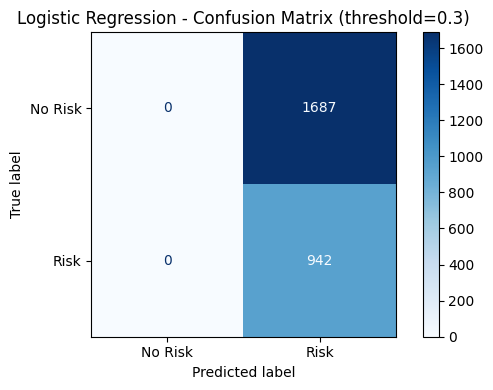


Random Forest:
------------------------------------------------------------
Confusion Matrix (threshold=0.3):
[[ 309 1378]
 [ 155  787]]

True Negatives (correct 0):  309
False Positives (wrong 1):   1378
False Negatives (wrong 0):   155
True Positives (correct 1):  787

Class 0 (No Risk) Recall: 0.1832 (18.3%)
Class 1 (Risk) Recall: 0.8355 (83.5%)
Class 1 (Risk) Precision: 0.3635 (36.4%)
Balanced Accuracy: 0.5093 (50.9%)
F1-Score: 0.5066


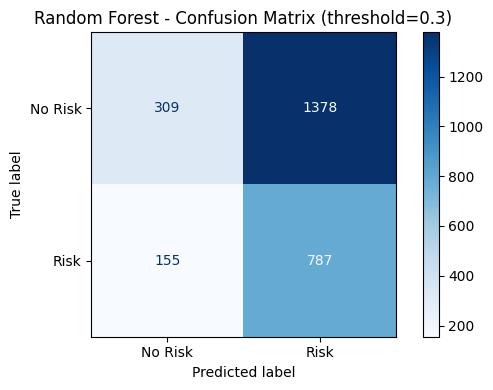


XGBoost:
------------------------------------------------------------
Confusion Matrix (threshold=0.3):
[[ 452 1235]
 [ 240  702]]

True Negatives (correct 0):  452
False Positives (wrong 1):   1235
False Negatives (wrong 0):   240
True Positives (correct 1):  702

Class 0 (No Risk) Recall: 0.2679 (26.8%)
Class 1 (Risk) Recall: 0.7452 (74.5%)
Class 1 (Risk) Precision: 0.3624 (36.2%)
Balanced Accuracy: 0.5066 (50.7%)
F1-Score: 0.4877


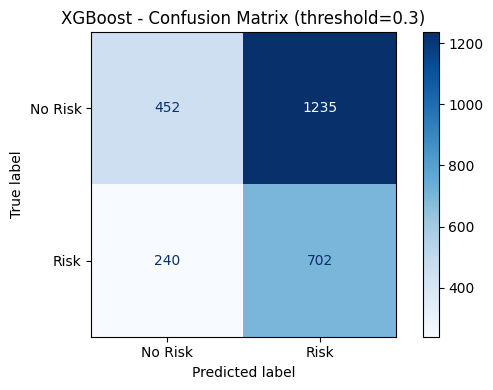


Gradient Boosting:
------------------------------------------------------------
Confusion Matrix (threshold=0.3):
[[ 189 1498]
 [  97  845]]

True Negatives (correct 0):  189
False Positives (wrong 1):   1498
False Negatives (wrong 0):   97
True Positives (correct 1):  845

Class 0 (No Risk) Recall: 0.1120 (11.2%)
Class 1 (Risk) Recall: 0.8970 (89.7%)
Class 1 (Risk) Precision: 0.3606 (36.1%)
Balanced Accuracy: 0.5045 (50.5%)
F1-Score: 0.5145


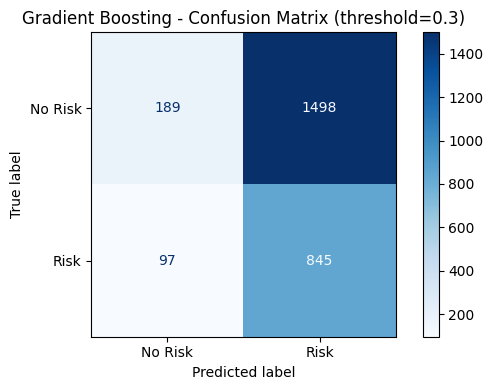

In [ ]:
#Попробуем снизить порог
threshold = 0.3

for name, pipeline in pipelines.items():
    print(f"\n{name}:")
    print("-"*60)

    # Get probabilities
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    # Apply custom threshold
    y_pred_custom = (y_proba >= threshold).astype(int)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_custom)

    print(f"Confusion Matrix (threshold={threshold}):")
    print(cm)
    print(f"\nTrue Negatives (correct 0):  {cm[0,0]}")
    print(f"False Positives (wrong 1):   {cm[0,1]}")
    print(f"False Negatives (wrong 0):   {cm[1,0]}")
    print(f"True Positives (correct 1):  {cm[1,1]}")

    # Calculate metrics
    tn, fp, fn, tp = cm.ravel()
    recall_0 = tn / (tn + fp) if (tn + fp) > 0 else 0
    recall_1 = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_1 = tp / (tp + fp) if (tp + fp) > 0 else 0
    balanced_acc = (recall_0 + recall_1) / 2
    f1 = 2 * (precision_1 * recall_1) / (precision_1 + recall_1) if (precision_1 + recall_1) > 0 else 0

    print(f"\nClass 0 (No Risk) Recall: {recall_0:.4f} ({recall_0*100:.1f}%)")
    print(f"Class 1 (Risk) Recall: {recall_1:.4f} ({recall_1*100:.1f}%)")
    print(f"Class 1 (Risk) Precision: {precision_1:.4f} ({precision_1*100:.1f}%)")
    print(f"Balanced Accuracy: {balanced_acc:.4f} ({balanced_acc*100:.1f}%)")
    print(f"F1-Score: {f1:.4f}")

    # Plot
    fig, ax = plt.subplots(figsize=(6, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Risk', 'Risk'])
    disp.plot(ax=ax, cmap='Blues')
    plt.title(f'{name} - Confusion Matrix (threshold={threshold})')
    plt.tight_layout()
    plt.show()

Выбрала THRESHOLD=0.3 (так как для медицинской задачи)

лучшиая модель - Random Forest
- Recall (Risk): 83.5%  находим большинство больных!
- Precision (Risk): 36.4%  много FP, но лучше поднять за счет этого recall
- Balanced Acc: 50.9%  чуть лучше рандома
- F1-Score: 0.507

TRADE-OFF:
Из 942 больных найдем 787 (83.5%)
Но будет 1378 ложных тревог (FP)
Для медицины лучше увеличить recall

Все модели показали ROC-AUC около 0.5, что говорит о том, что они работают не лучше случайного угадывания. Даже применение class_weight='balanced' и снижение порога до 0.3 помогли увеличить Recall для класса с риском, но это привело к большому количеству ложных тревог, а общая предсказательная способность не улучшилась. Корреляции признаков с таргетом оказались очень слабыми (0.01-0.02), поэтому проблема скорее всего в самих данных, они просто не содержат достаточно информации для предсказания
